# 발현 회복 파이프라인 (Expression Rescue Pipeline)

항체-항원 결합 복합체 PDB가 주어졌을 때, 이 노트북은 항원 결합을 방해하지 않으면서 항체 발현을 회복(rescue)할 수 있는 CDR 루프의 단일 점 돌연변이(single-point mutations)를 제안합니다.

> ⚠ 최종 출력물은 6단계(Step 6) 마지막에 출력되는 선택된 회복 돌연변이 목록입니다 (예: `V52S, S108L, T100L`). 그 외의 히트맵, 로짓 색상 PDB, 잔기별 CSV 및 3D 뷰는 이러한 돌연변이가 어떻게 선택되었는지 이해를 돕기 위한 추가 정보입니다.

> ⚠ 출력 품질은 입력 구조의 품질에 따라 달라집니다. 이 파이프라인은 잔기별 구조적 컨텍스트(백본 기하학 + 로컬 환경)를 읽어 모든 하류 결정을 내리는 로짓을 생성합니다. 입력 복합체의 해상도가 낮거나, 잘못 접힌 영역이 있거나, 품질이 좋지 않은 경우 결과로 나오는 회복 돌연변이를 신뢰하지 못할 수 있습니다. 고해상도 결정/초저온 전자현미경(cryo-EM) 구조 또는 에너지 최소화가 완료되고 결합 인터페이스가 검증된 고품질 예측 구조를 사용하는 것이 좋습니다.

방법. 우리는 두 가지 상태에 대해 ProteinMPNN 단일 아미노산 스코어링을 실행합니다:

- bound (결합 상태): 입력된 복합체 그대로
- unbound (비결합 상태): 항원 체인이 제거된 동일한 복합체

ProteinMPNN은 구조적 컨텍스트를 조건으로 하는 21개 아미노산 알파벳에 대해 잔기별 로짓을 생성합니다. 두 상태를 잔기별로 비교하면 두 가지 실행 가능한 신호를 얻을 수 있습니다:

| 신호 | 정의 | 해석 |
|--------|------------|----------------|
| 핵심 결합 잔기 | 결합 상태의 야생형(WT) 아미노산 로짓이 비결합 상태보다 훨씬 높은 위치 (Δ = logit_bound - logit_unbound > threshold) | 해당 잔기는 항원과의 접촉 때문에 선호됩니다. 이를 변경하면 결합 친화력이 저하될 가능성이 높습니다. |
| 회복 후보 | 비결합 상태에서 다른 아미노산의 로짓이 현재 야생형 아미노산보다 높은 위치 | 해당 잔기는 항체 단독 상태에서 이미 최적이 아닙니다. 치환을 통해 결합 인터페이스를 건드리지 않고도 발현/안정성을 개선할 수 있습니다. |

이 노트북은 실행당 하나의 입력 복합체에 대해 엔드-투-엔드로 실행됩니다. 아래의 사용자 입력 셀을 설정하고 모든 셀을 실행하십시오.

In [1]:
import re
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import py3Dmol
import seaborn as sns
import torch
from IPython.display import HTML, Markdown, display

from prody import parsePDB, writePDB

print(torch.cuda.is_available(), torch.cuda.device_count())

True 1


## 0단계 - 사용자 입력 받기

초기 항체-항원 복합체 PDB, 항원 및 회복 잔기 정보, 출력 디렉토리, 다양한 하이퍼파라미터 등을 포함한 사용자 입력을 받습니다. 이 셀을 수정한 후 '모두 실행(Run All)' 하십시오.

In [2]:
# 입력 구조: 항체-항원 복합체 PDB 파일.
bound_pdb_path = "example/260514_XXX_VHH(ALB23).pdb"

# 항원의 체인 문자. 그 외 모든 것은 항체로 처리됩니다.
# 예시 PDB는 체인 A, B, C에 동형 삼량체 항원을 가지고 있고, D(중쇄) + G(경쇄)에 항체를 가지고 있습니다.
antigen_chain_ids = ["A"]

# 회복 평가 대상 잔기 (CDR 위치, 핫스팟 등).
# 형식: "<체인 문자><잔기 번호>" 문자열.
rescue_residues = [
    # FR1
    "B2",
    "B4",
    # CDR-H1
    "B26",
    "B27",
    "B28",
    "B29",
    "B30",
    "B31",
    "B32",
    "B33",
    # CDR-H2
    "B51",
    "B52",
    "B53",
    "B54",
    "B55",
    "B56",
    "B57",
    "B58",
    # CDR-H3
    "B97",
    "B98",
    "B99",
    "B100",
    "B101",
    "B102",
    "B103",
    "B104",
]

# 출력 디렉토리 (없으면 생성됨).
output_dir = "output"

# ProteinMPNN 스코어링 백엔드 (이 노트북과 함께 제공됨).
protein_mpnn_dir = "ProteinMPNN"
weights_path = "ProteinMPNN/model_params/proteinmpnn_v_48_020.pt"

# 분석 임계값 / 설정.
binding_logit_threshold = 1.0  # 델타 > 임계값 -> 핵심 결합 잔기 (5단계)
top_k_rescue = 10  # 6단계에서 야생형 선호도가 가장 낮은 상위 K개 위치 강조

# ----- 선택 사항: 사용자 제공 핵심 결합 잔기 -----
# 실험적 돌연변이 생성, 기존 문헌, 에피토프 매핑 등을 통해 특정 위치가
# 결합에 중요하다는 것을 이미 알고 있는 경우 여기에 나열하십시오.
# 파이프라인의 Δ 기반 감지에 전적으로 의존하려면 비워 두십시오.
user_key_binding_residues = ["B32"]

# 사용자 제공 잔기를 5단계의 Δ 기반 감지와 결합하는 방법.
# user_key_binding_residues가 비어 있지 않은 경우에만 참조됩니다.
#   "union"     — final set = pipeline-detected ∪ user-supplied (most conservative)
#   "user_only" — final set = user-supplied only (pipeline Δ detection ignored)
user_key_binding_mode = "union"  # "union" | "user_only"

# 스코어링 하이퍼파라미터 (참조 연구에서 사용된 값과 일치함).
batch_size = 10
number_of_batches = 1

# 절대 경로로 변환하고 출력 서브 디렉토리를 생성합니다.
bound_pdb_path = str(Path(bound_pdb_path).resolve())
output_dir = Path(output_dir).resolve()
bound_out_dir = output_dir / "bound"
unbound_out_dir = output_dir / "unbound"
for d in (output_dir, bound_out_dir, unbound_out_dir):
    d.mkdir(parents=True, exist_ok=True)

stem = Path(bound_pdb_path).stem
print(f"Input PDB  : {bound_pdb_path}")
print(f"Output dir : {output_dir}")
print(f"Rescue residues: {len(rescue_residues)}")
if user_key_binding_residues:
    print(
        f"User-specified key-binding residues: {user_key_binding_residues}  (mode='{user_key_binding_mode}')"
    )
else:
    print("User-specified key-binding residues: (none — pipeline detection only)")

Input PDB  : /home/fkt/Downloads/repo/ab-expression-rescue/example/260514_XXX_VHH(ALB23).pdb
Output dir : /home/fkt/Downloads/repo/ab-expression-rescue/output
Rescue residues: 26
User-specified key-binding residues: ['B32']  (mode='union')


## 1단계 - 비결합 상태(unbound) PDB 생성

결합된 복합체에서 항원 체인을 제거하고 동반 PDB 파일을 작성합니다. 이 파일은 ProteinMPNN의 "unbound" 입력값이 됩니다. 항체 좌표는 동일하지만 항원 컨텍스트는 없습니다.

In [3]:
unbound_pdb_path = output_dir / f"{stem}_unbound.pdb"

bound_structure = parsePDB(bound_pdb_path)
if bound_structure is None:
    raise RuntimeError(f"ProDy failed to parse {bound_pdb_path}")

antigen_selector = " or ".join(f"chain {c}" for c in antigen_chain_ids)
antibody_selection = bound_structure.select(f"not ({antigen_selector})")
if antibody_selection is None:
    raise RuntimeError(
        f"Removing chains {antigen_chain_ids} left no atoms - check antigen_chain_ids."
    )

writePDB(str(unbound_pdb_path), antibody_selection)

n_bound = bound_structure.numAtoms()
n_unbound = antibody_selection.numAtoms()
print(f"결합 상태 원자 수 : {n_bound}")
print(f"비결합 상태 원자 수: {n_unbound}  ({n_bound - n_unbound}개의 항원 원자 제거)")
print(f"비결합 PDB 작성 완료 -> {unbound_pdb_path}")

결합 상태 원자 수 : 5405
비결합 상태 원자 수: 852  (4553개의 항원 원자 제거)
비결합 PDB 작성 완료 -> /home/fkt/Downloads/repo/ab-expression-rescue/output/260514_XXX_VHH(ALB23)_unbound.pdb


## 2단계 - ProteinMPNN 스코어링 실행

번들로 제공되는 `ProteinMPNN/score.py`를 각 상태에 대해 한 번씩, 총 두 번 호출합니다. 스코어링 모드는 다음과 같습니다:

- `--single_aa_score 1` - p(AA_i | backbone, AA_{i를 제외한 모든 것})
- `--use_sequence 1` - 천연 서열을 조건으로 함 (결합 상태: 전체 복합체 서열, 비결합 상태: 항체 단독 서열)

각 실행은 `output/{bound,unbound}/` 내에 단일 `.pt` 파일을 생성합니다.

In [4]:
def run_scoring(pdb_path, out_folder):
    """하나의 PDB에 대해 ProteinMPNN/score.py를 호출합니다. 작성된 .pt 파일의 경로를 반환합니다."""
    cmd = [
        sys.executable,
        "-u",
        "score.py",
        "--pdb_path",
        str(pdb_path),
        "--out_folder",
        str(out_folder),
        "--model_type",
        "protein_mpnn",
        "--checkpoint_protein_mpnn",
        str(Path(weights_path).resolve()),
        "--batch_size",
        str(batch_size),
        "--number_of_batches",
        str(number_of_batches),
        "--single_aa_score",
        "1",
        "--use_sequence",
        "1",
    ]
    print("$", " ".join(cmd))
    subprocess.run(cmd, cwd=str(Path(protein_mpnn_dir).resolve()), check=True)
    pt_path = Path(out_folder) / f"{Path(pdb_path).stem}.pt"
    if not pt_path.exists():
        raise RuntimeError(f"Expected scoring output not found: {pt_path}")
    return pt_path


bound_pt = run_scoring(bound_pdb_path, bound_out_dir)
unbound_pt = run_scoring(unbound_pdb_path, unbound_out_dir)
print(f"\nBound scores  : {bound_pt}")
print(f"Unbound scores: {unbound_pt}")

$ /home/fkt/Downloads/repo/ab-expression-rescue/.pixi/envs/default/bin/python -u score.py --pdb_path /home/fkt/Downloads/repo/ab-expression-rescue/example/260514_XXX_VHH(ALB23).pdb --out_folder /home/fkt/Downloads/repo/ab-expression-rescue/output/bound --model_type protein_mpnn --checkpoint_protein_mpnn /home/fkt/Downloads/repo/ab-expression-rescue/ProteinMPNN/model_params/proteinmpnn_v_48_020.pt --batch_size 10 --number_of_batches 1 --single_aa_score 1 --use_sequence 1
Designing protein from this path: /home/fkt/Downloads/repo/ab-expression-rescue/example/260514_XXX_VHH(ALB23).pdb
These residues will be redesigned:  ['A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19', 'A20', 'A21', 'A22', 'A23', 'A24', 'A25', 'A26', 'A27', 'A28', 'A29', 'A30', 'A31', 'A32', 'A33', 'A34', 'A35', 'A36', 'A37', 'A38', 'A39', 'A40', 'A41', 'A42', 'A43', 'A44', 'A45', 'A46', 'A47', 'A48', 'A49', 'A50', 'A51', 'A52', 'A53', 'A54', 'A55', 'A56', 'A57', 'A

## 3단계 - 스코어링 결과 로드

`.pt` 파일에는 각 스코어링 실행당 집계된 딕셔너리가 들어 있습니다. 필요한 키는 다음과 같습니다:

- `mean_of_logits`: `"<chain><resnum>"` -> `{AA letter -> logit}` 매핑 딕셔너리
- `sequence`: `residue_names`에 정렬된 야생형(WT) 아미노산 문자 리스트
- `residue_names`: 정수 인덱스 -> `"<chain><resnum>"` 문자열 매핑 딕셔너리

In [5]:
bound_data = torch.load(bound_pt, map_location="cpu", weights_only=False)
unbound_data = torch.load(unbound_pt, map_location="cpu", weights_only=False)

bound_logits = bound_data["mean_of_logits"]
unbound_logits = unbound_data["mean_of_logits"]
alphabet = bound_data["alphabet"]


# residue_name -> WT AA 문자로 매핑 (정수 인덱스 서열 + residue_names 사용).
def wt_map(data):
    idx_to_name = data["residue_names"]
    seq = data["sequence"]
    return {idx_to_name[i]: seq[i] for i in range(len(seq))}


wt_bound = wt_map(bound_data)
wt_unbound = wt_map(unbound_data)

missing_bound = [r for r in rescue_residues if r not in bound_logits]
missing_unbound = [r for r in rescue_residues if r not in unbound_logits]
if missing_bound or missing_unbound:
    raise KeyError(
        "Rescue residues not found in scoring output:\n"
        f"  bound   missing: {missing_bound}\n"
        f"  unbound missing: {missing_unbound}\n"
        "Check chain letters and residue numbers in the input PDB."
    )

print(f"알파벳 ({len(alphabet)}개): {''.join(alphabet)}")
print(f"스코어링된 결합 잔기 수  : {len(bound_logits)}")
print(f"스코어링된 비결합 잔기 수: {len(unbound_logits)}")

알파벳 (21개): ACDEFGHIKLMNPQRSTVWYX
스코어링된 결합 잔기 수  : 688
스코어링된 비결합 잔기 수: 115


## 4단계 - 잔기별 로짓 행렬 수집

각 회복 잔기에 대해 21개 아미노산 알파벳에 걸쳐 결합 및 비결합 로짓을 쌓습니다. 행은 먼저 체인 문자로 정렬된 다음 잔기 번호로 정렬됩니다 (예: 사전순인 `B100`이 `B30` 앞에 오는 것이 아니라 `B30, B31, ..., C24, C25, ...` 순서).

In [6]:
def res_sort_key(name):
    """'B30' -> ('B', 30). 단일 문자 체인을 가정합니다. 다중 문자 체인을 사용하는 경우 확장하십시오."""
    m = re.match(r"([A-Za-z]+)(\d+)", name)
    if not m:
        raise ValueError(f"Cannot parse residue name: {name}")
    return (m.group(1), int(m.group(2)))


ordered_residues = sorted(rescue_residues, key=res_sort_key)
n_res = len(ordered_residues)
n_aa = len(alphabet)

bound_mat = np.zeros((n_res, n_aa), dtype=float)
unbound_mat = np.zeros((n_res, n_aa), dtype=float)
wt_aas = []

for i, res in enumerate(ordered_residues):
    b = bound_logits[res]
    u = unbound_logits[res]
    bound_mat[i] = [b.get(aa, 0.0) for aa in alphabet]
    unbound_mat[i] = [u.get(aa, 0.0) for aa in alphabet]
    wt = wt_bound[res]
    if wt_unbound[res] != wt:
        print(f"[warn] WT mismatch at {res}: bound={wt} unbound={wt_unbound[res]}")
    wt_aas.append(wt)

diff_mat = bound_mat - unbound_mat
print(f"{n_res}개 잔기 x {n_aa}개 아미노산에 대한 로짓 수집 완료.")

26개 잔기 x 21개 아미노산에 대한 로짓 수집 완료.


## 5단계 - 핵심 결합 잔기 식별

각 회복 잔기에 대해 Δ = logit_bound(WT) − logit_unbound(WT)를 계산합니다. Δ > `binding_logit_threshold`인 잔기는 결합에 중요한 것으로 표시됩니다. 즉, 항원과의 접촉이 현재의 야생형 아미노산을 선호하게 만드는 요인임을 의미합니다.

**선택적 사용자 재정의.** 만약 `user_key_binding_residues`가 비어 있지 않다면, 하류에서 사용되는 최종 핵심 결합 세트는 다음과 같습니다:

- `"union"` — 파이프라인 감지 결과 ∪ 사용자 제공 결과
- `"user_only"` — 사용자 제공 결과만 사용 (파이프라인 Δ 감지 무시)

투명성을 위해 Δ 기반 플래그(`is_key_binding`)와 사용자 플래그(`user_specified`) 모두 `key_binding_residues.csv`에 유지되지만, 실제로 6단계의 상위 K개 제외를 구동하는 열은 `is_final_key_binding`입니다.

In [7]:
aa_to_col = {aa: i for i, aa in enumerate(alphabet)}

# ── Δ 기반 감지 ────────────────────────────────────────────────────
key_rows = []
for i, (res, wt) in enumerate(zip(ordered_residues, wt_aas)):
    col = aa_to_col[wt]
    b = float(bound_mat[i, col])
    u = float(unbound_mat[i, col])
    key_rows.append(
        {
            "position": res,
            "WT_aa": wt,
            "WT_bound_logit": b,
            "WT_unbound_logit": u,
            "delta": b - u,
            "is_key_binding": (b - u) > binding_logit_threshold,
        }
    )

# ── 사용자 제공 잔기와 결합 ──────────────────────────────────
pipeline_kb = {r["position"] for r in key_rows if r["is_key_binding"]}
user_kb_requested = set(user_key_binding_residues)
user_kb_unknown = user_kb_requested - set(ordered_residues)
user_kb = user_kb_requested & set(ordered_residues)

if not user_kb:
    final_key_binding_positions = pipeline_kb
    mode_note = "no user input — pipeline detection only"
elif user_key_binding_mode == "union":
    final_key_binding_positions = pipeline_kb | user_kb
    mode_note = f"union ({len(pipeline_kb)} pipeline ∪ {len(user_kb)} user)"
elif user_key_binding_mode == "user_only":
    final_key_binding_positions = user_kb
    mode_note = f"user_only ({len(user_kb)} user; Δ detection ignored)"
else:
    raise ValueError(
        f"Unknown user_key_binding_mode: {user_key_binding_mode!r} "
        "(use 'union' or 'user_only')."
    )

for row in key_rows:
    row["user_specified"] = row["position"] in user_kb
    row["is_final_key_binding"] = row["position"] in final_key_binding_positions

# ── 데이터프레임 + CSV 저장 ─────────────────────────────────────────────────
df_key = (
    pd.DataFrame(key_rows).sort_values("delta", ascending=False).reset_index(drop=True)
)
key_csv = output_dir / "key_binding_residues.csv"
df_key.to_csv(key_csv, index=False)

# ── 스타일링된 디스플레이 ───────────────────────────────────────────────────────
max_abs_delta = max(abs(df_key["delta"].min()), abs(df_key["delta"].max()), 1e-6)
non_gradient_cols = [c for c in df_key.columns if c != "delta"]


def _highlight_final(row):
    if row["is_final_key_binding"]:
        return ["background-color: #fff3cd"] * len(row)
    return [""] * len(row)


styled = (
    df_key.style.format(
        {
            "WT_bound_logit": "{:+.3f}",
            "WT_unbound_logit": "{:+.3f}",
            "delta": "{:+.3f}",
        }
    )
    .background_gradient(
        cmap="coolwarm_r",
        subset=["delta"],
        vmin=-max_abs_delta,
        vmax=max_abs_delta,
    )
    .apply(_highlight_final, axis=1, subset=non_gradient_cols)
    .set_caption(f"5단계 — 핵심 결합 잔기 · {mode_note}")
    .hide(axis="index")
)
display(styled)

# ── 요약 ──────────────────────────────────────────────────────────────
n_delta = sum(r["is_key_binding"] for r in key_rows)
n_user = sum(r["user_specified"] for r in key_rows)
n_final = sum(r["is_final_key_binding"] for r in key_rows)
msg = (
    f"**{n_final}** 잔기가 최종 핵심 결합 세트에 포함됨 "
    f"(Δ-표시됨: {n_delta} · 사용자 지정: {n_user}) — 위에서 노란색으로 강조됨; "
    f"6단계에서는 회복 대상을 선택할 때 이를 제외합니다."
)
if user_kb_unknown:
    msg += (
        f"\n\n⚠️ User residues not in `rescue_residues` (ignored): "
        f"{sorted(user_kb_unknown)}"
    )
display(Markdown(msg))
print(f"{key_csv} 작성 완료")

position,WT_aa,WT_bound_logit,WT_unbound_logit,delta,is_key_binding,user_specified,is_final_key_binding
B33,G,+5.192,+0.082,+5.110,True,False,True
B99,G,+5.465,+0.861,+4.604,True,False,True
B32,F,+3.894,+0.244,+3.651,True,True,True
B98,I,+4.943,+3.010,+1.933,True,False,True
B2,V,+4.661,+2.764,+1.896,True,False,True
B57,D,+0.638,-0.637,+1.275,True,False,True
B27,F,+4.759,+3.748,+1.011,True,False,True
B101,S,+2.394,+1.504,+0.890,False,False,False
B53,G,+4.583,+4.256,+0.326,False,False,False
B29,F,+4.208,+3.957,+0.250,False,False,False


**7** 잔기가 최종 핵심 결합 세트에 포함됨 (Δ-표시됨: 7 · 사용자 지정: 1) — 위에서 노란색으로 강조됨; 6단계에서는 회복 대상을 선택할 때 이를 제외합니다.

/home/fkt/Downloads/repo/ab-expression-rescue/output/key_binding_residues.csv 작성 완료


## 6단계 - WT 비결합 선호도에 따른 위치 순위 지정 (핵심 결합 잔기 제외)

모든 회복 잔기를 야생형 아미노산의 **비결합(unbound)** 로짓에 따라 오름차순으로 정렬하여 나열합니다. 표의 상단은 항체 단독 모델이 현재 잔기에 대해 가장 만족하지 못하는 위치이며, 이는 가장 강력한 발현 회복 대상이 됩니다.

**최종 핵심 결합 세트(5단계)에 포함된 잔기는 투명성을 위해 표에는 유지되지만 상위 K개 돌연변이를 선택할 때는 제외됩니다** — 항원 인터페이스를 손상시킬 수 있는 교체는 권장하지 않기 때문입니다. 따라서 상위 K개는 남은 잔기 중에서만 선택됩니다.

최종 핵심 결합 세트는 다음과 같음을 상기하십시오:

- `user_key_binding_residues`가 비어 있는 경우 Δ 기반 감지만 수행 (기본값)
- `"union"` 모드인 경우 `pipeline ∪ user`
- `"user_only"` 모드인 경우 `user` 전용

각 위치에 대해 비결합 로짓이 가장 높은 아미노산(`best_aa`)과 야생형과의 로짓 차이(`logit_diff`)도 보고합니다. 이것이 논문에서 각 선택된 위치에 도입하는 치환입니다.

In [8]:
# final_key_binding_positions는 5단계 끝에서 계산되었습니다.

ranking_rows = []
for i, (res, wt) in enumerate(zip(ordered_residues, wt_aas)):
    u_vec = unbound_mat[i]
    wt_col = aa_to_col[wt]
    wt_u = float(u_vec[wt_col])
    best_col = int(np.argmax(u_vec))
    best_aa = alphabet[best_col]
    best_u = float(u_vec[best_col])
    ranking_rows.append(
        {
            "position": res,
            "WT_aa": wt,
            "WT_unbound_logit": wt_u,
            "best_aa": best_aa,
            "best_unbound_logit": best_u,
            "logit_diff": best_u - wt_u,
            "is_key_binding": res in final_key_binding_positions,
        }
    )

# 야생형 비결합 로짓 오름차순 → 가장 덜 선호되는 야생형이 상단에 위치.
ranking_rows.sort(key=lambda r: r["WT_unbound_logit"])
for rank, row in enumerate(ranking_rows, start=1):
    row["rank"] = rank

# 핵심 결합 잔기가 아닌 잔기 중에서만 상위 K개를 선택합니다.
selectable = [r for r in ranking_rows if not r["is_key_binding"]]
selected_positions = {r["position"] for r in selectable[:top_k_rescue]}
for row in ranking_rows:
    row["top_k"] = row["position"] in selected_positions

# ── 데이터프레임 + CSV 저장 ─────────────────────────────────────────────────
df_rank = pd.DataFrame(ranking_rows)[
    [
        "rank",
        "position",
        "WT_aa",
        "WT_unbound_logit",
        "best_aa",
        "best_unbound_logit",
        "logit_diff",
        "is_key_binding",
        "top_k",
    ]
]
ranking_csv = output_dir / "rescue_ranking.csv"
df_rank.to_csv(ranking_csv, index=False)

# ── 최종 출력: 주요 회복 돌연변이 ────────────────────
top_rows = sorted(
    [r for r in ranking_rows if r["top_k"]],
    key=lambda r: r["WT_unbound_logit"],
)
mut_strs = [f"{r['WT_aa']}{r['position'][1:]}{r['best_aa']}" for r in top_rows]
mut_display = (
    " · ".join(mut_strs)
    if mut_strs
    else "(none — all candidate residues are in the key-binding set)"
)

display(
    HTML(f"""
<div style="border:2px solid #28a745; border-radius:10px; padding:18px 22px;
            background:#f0fdf4; margin:16px 0;">
  <div style="color:#52525b; font-size:11px; letter-spacing:0.16em;
              font-weight:700; text-transform:uppercase; margin-bottom:10px;">
    최종 회복 돌연변이 · 상위 {top_k_rescue}개
  </div>
  <div style="font-family: Menlo, Monaco, Consolas, monospace; font-size:26px;
              font-weight:700; color:#14532d; letter-spacing:0.02em;">
    {mut_display}
  </div>
  <div style="color:#166534; font-size:13px; margin-top:12px; line-height:1.5;">
    이 {len(top_rows)}개의 치환을 항체 서열에 도입하십시오.
    아래의 순위표는 이러한 위치가 어떻게
    선택되었는지 설명하는 추가 정보입니다.
  </div>
</div>
""")
)

# ── 스타일링된 순위표 ─────────────────────────────
non_gradient_cols_rank = [c for c in df_rank.columns if c != "WT_unbound_logit"]


def _highlight_row(row):
    # top_k rows: saturated green fill + bold text
    # key-binding rows: medium-gray fill
    if row["top_k"]:
        return ["background-color: #86efac; font-weight: 700"] * len(row)
    if row["is_key_binding"]:
        return ["background-color: #d1d5db"] * len(row)
    return [""] * len(row)


styled_rank = (
    df_rank.style.format(
        {
            "WT_unbound_logit": "{:+.3f}",
            "best_unbound_logit": "{:+.3f}",
            "logit_diff": "{:+.3f}",
        }
    )
    .background_gradient(cmap="bwr_r", subset=["WT_unbound_logit"])
    .apply(_highlight_row, axis=1, subset=non_gradient_cols_rank)
    .set_caption(
        f"6단계 — 회복 순위 · "
        f"녹색 = 선택됨 (상위 {top_k_rescue}개) · "
        f"회색 = 핵심 결합 (제외됨)"
    )
    .hide(axis="index")
)
display(styled_rank)

n_excluded = sum(r["is_key_binding"] for r in ranking_rows)
display(
    Markdown(
        f"{n_excluded} 개 잔기가 핵심 결합으로 제외됨 (위의 회색 행); "
        f"남은 {len(ranking_rows) - n_excluded}개 중에서 상위 {top_k_rescue}개를 선택했습니다."
    )
)
print(f"{ranking_csv} 작성 완료")

rank,position,WT_aa,WT_unbound_logit,best_aa,best_unbound_logit,logit_diff,is_key_binding,top_k
1,B30,R,-0.770,S,+2.735,+3.505,False,True
2,B57,D,-0.637,S,+0.872,+1.509,True,False
3,B28,T,-0.105,D,+2.874,+2.978,False,True
4,B33,G,+0.082,S,+1.471,+1.389,True,False
5,B32,F,+0.244,H,+2.077,+1.833,True,False
6,B103,S,+0.723,E,+0.755,+0.031,False,True
7,B99,G,+0.861,N,+2.428,+1.567,True,False
8,B56,S,+1.151,S,+1.151,+0.000,False,True
9,B101,S,+1.504,S,+1.504,+0.000,False,True
10,B58,T,+1.536,T,+1.536,+0.000,False,True


7 개 잔기가 핵심 결합으로 제외됨 (위의 회색 행); 남은 19개 중에서 상위 10개를 선택했습니다.

/home/fkt/Downloads/repo/ab-expression-rescue/output/rescue_ranking.csv 작성 완료


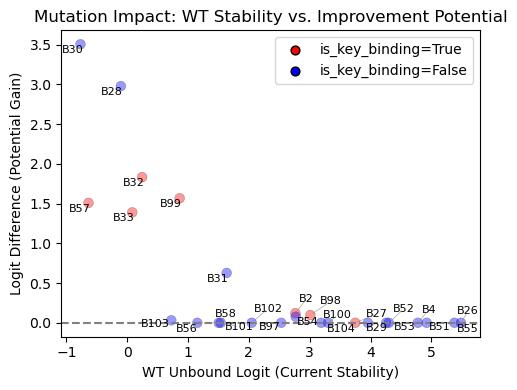

In [16]:
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(5, 4))

# 색상 매핑
color_map = {True: "red", False: "blue"}
colors = df_rank["is_key_binding"].map(color_map)

# scatter plot (포인트 크기와 alpha 조정)
scatter = ax.scatter(
    df_rank["WT_unbound_logit"],
    df_rank["logit_diff"],
    c=colors,
    alpha=0.4,
    s=50,
    edgecolor="k",
    linewidth=0.3
)

# 수평선 y=0
ax.axhline(y=0, linestyle="--", color="gray")

# 라벨 및 제목
ax.set_xlabel("WT Unbound Logit (Current Stability)")
ax.set_ylabel("Logit Difference (Potential Gain)")
ax.set_title("Mutation Impact: WT Stability vs. Improvement Potential")

# 텍스트 어노테이션을 만들고 adjust_text로 겹침 해소
texts = []
for i, row in df_rank.iterrows():
    x = row["WT_unbound_logit"]
    y = row["logit_diff"]
    txt = ax.text(x, y, str(row["position"]),
                  fontsize=8, ha="center", va="center",
                  bbox=dict(facecolor="white", alpha=0.0, boxstyle="round,pad=0.1"))
    texts.append(txt)

# adjust_text 호출: 텍스트는 이동시키고 포인트로 화살표 연결
adjust_text(
    texts,
    x=df_rank["WT_unbound_logit"].values,
    y=df_rank["logit_diff"].values,
    arrowprops=dict(arrowstyle="-", color="gray", lw=0.5, alpha=0.7),
    expand_text=(1.0, 1.0),
    expand_points=(1.2, 1.2),
    force_text=0.5,
    force_points=0.5,
    only_move={'points':'y', 'texts':'xy'}
)

# 범례 추가 (더 깔끔하게)
for key, color in color_map.items():
    ax.scatter([], [], c=color, label=f"is_key_binding={key}", edgecolor="k", s=40)
ax.legend(frameon=True)

plt.tight_layout()
plt.show()

#### 델타 로짓 분포 (Delta Logit Distribution)

항원 결합에 의해 아미노산 선호도가 얼마나 민감하게 변하는지 전체적인 분포를 확인합니다. 
* 해석: 임계값(Threshold) 오른쪽에 있는 잔기들이 항체-항원 인터페이스에서 중요한 역할을 함을 시각적으로 보여줍니다.

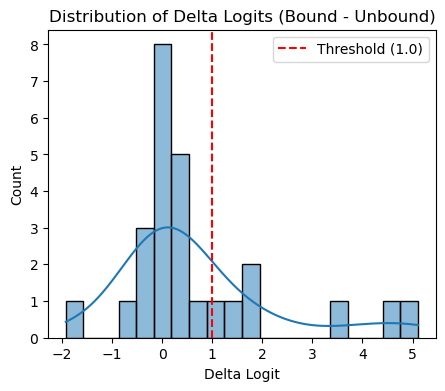

In [10]:
plt.figure(figsize=(5, 4))
sns.histplot(df_key["delta"], bins=20, kde=True)
plt.axvline(
    x=binding_logit_threshold,
    color="red",
    linestyle="--",
    label=f"Threshold ({binding_logit_threshold})",
)
plt.title("Distribution of Delta Logits (Bound - Unbound)")
plt.xlabel("Delta Logit")
plt.legend()
plt.show()

####  아미노산 선택 확률 엔트로피 (Sequence Entropy)

특정 위치에서 ProteinMPNN이 얼마나 확신을 가지고 아미노산을 추천하는지(Entropy)를 시각화합니다. 엔트로피가 낮을수록 특정 아미노산에 대한 선호도가 매우 뚜렷함을 의미합니다.


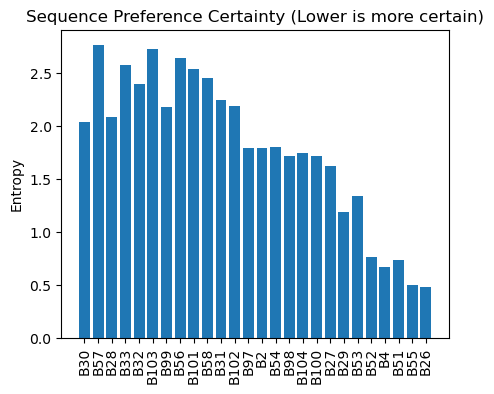

In [11]:
def calculate_entropy(logits_vec):
    probs = np.exp(logits_vec) / np.sum(np.exp(logits_vec))
    return -np.sum(probs * np.log(probs + 1e-9))


entropies = [calculate_entropy(unbound_mat[i]) for i in range(n_res)]
df_rank["entropy"] = [entropies[ordered_residues.index(r)] for r in df_rank["position"]]

plt.figure(figsize=(5, 4))
plt.bar(df_rank["position"], df_rank["entropy"])
plt.title("Sequence Preference Certainty (Lower is more certain)")
plt.ylabel("Entropy")
plt.xticks(rotation=90)
plt.show()

#### 거리 기반 인터페이스 검증 (Distance vs. Delta Plot)

추출된 $\Delta$ 값이 실제로 항원과의 거리와 상관관계가 있는지 확인하여 파이프라인의 신뢰도를 높입니다. (ProDy를 사용하여 거리를 계산하는 로직이 추가로 필요합니다.)

항원 거리 계산 중...


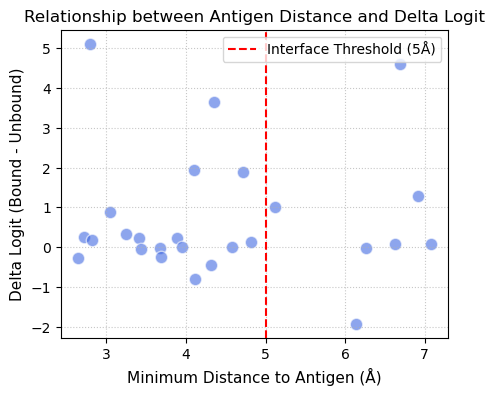

상관계수 (Distance vs Delta): 0.019


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 항원(Antigen) 선택
# 예: antigen_sel = bound_structure.select('chain C D')
antigen_sel = bound_structure.select(f"chain {' '.join(antigen_chain_ids)}")

interface_distances = []

print("항원 거리 계산 중...")

for res_id in ordered_residues:
    # 1. 체인과 번호 분리 로직 수정
    if "_" in res_id:
        # 'A_10' 형식인 경우
        ch, num = res_id.split("_")
    else:
        # 'A10' 형식인 경우 (첫 글자는 체인, 나머지는 번호)
        ch = res_id[0]
        num = res_id[1:]

    # 2. ProDy 선택 쿼리 실행
    # (resnum 뒤에 있을 수 있는 공백 제거를 위해 num.strip() 권장)
    res_atoms = bound_structure.select(f"chain {ch} and resnum {num.strip()}")

    if res_atoms and antigen_sel:
        from scipy.spatial.distance import cdist

        dists = cdist(res_atoms.getCoords(), antigen_sel.getCoords())
        min_dist = dists.min()
        interface_distances.append(min_dist)
    else:
        # 구조에서 해당 잔기를 찾지 못한 경우
        interface_distances.append(np.nan)

# 2. 결과 데이터 프레임에 거리 정보 추가 (검증용)
df_key["dist_to_antigen"] = interface_distances

# 3. 시각화 (Distance vs Delta Plot)
plt.figure(figsize=(5, 4))
# 데이터가 존재하는 것만 산점도 그리기
valid_mask = ~np.isnan(interface_distances)
plt.scatter(
    np.array(interface_distances)[valid_mask],
    df_key["delta"][valid_mask],
    alpha=0.6,
    edgecolors="w",
    s=80,
    c="royalblue",
)

# 거리가 가까울수록(인터페이스) Delta 값이 큰 경향이 있는지 확인하기 위한 기준선(예: 5.0Å)
plt.axvline(x=5.0, color="red", linestyle="--", label="Interface Threshold (5Å)")

plt.title("Relationship between Antigen Distance and Delta Logit", fontsize=12)
plt.xlabel("Minimum Distance to Antigen (Å)", fontsize=11)
plt.ylabel("Delta Logit (Bound - Unbound)", fontsize=11)
plt.grid(axis="both", linestyle=":", alpha=0.7)
plt.legend()

plt.show()

# 상관계수 출력
correlation = df_key[["dist_to_antigen", "delta"]].corr().iloc[0, 1]
print(f"상관계수 (Distance vs Delta): {correlation:.3f}")

상관계수 0.018은 통계적으로 **"두 변수 사이에 선형적인 상관관계가 거의 없다"**는 것을 의미합니다. 항원과의 거리와 ProteinMPNN의 Logit 변화량($\Delta$)이 서로 무관하게 움직이고 있다는 뜻입니다. 따라서 분석 중인 후보군이 항원 결합 부위에서 멀리 떨어진 '안정성 개선 후보'들이라면 이 결과는 큰 문제가 아니지만, '인터페이스 잔기'를 분석 중이었다면 파이프라인 설정을 재검토해볼 필요가 있습니다.

#### 파일로 저장

In [13]:
# ── 히트맵 행렬 저장 (bound_mat, unbound_mat, diff_mat) ───────────────────────────
# 히트맵 시각화와 동일한 잔기 레이블 생성 (예: Y33, C34 등)
residue_labels = [f"{wt}{res[1:]}" for wt, res in zip(wt_aas, ordered_residues)]

# pandas DataFrame으로 변환 (행: 잔기 위치, 열: 20개 아미노산)
df_bound = pd.DataFrame(bound_mat, index=residue_labels, columns=alphabet)
df_unbound = pd.DataFrame(unbound_mat, index=residue_labels, columns=alphabet)
df_diff = pd.DataFrame(diff_mat, index=residue_labels, columns=alphabet)

# CSV 파일로 저장 (output_dir 경로 사용)
df_bound.to_csv(output_dir / "bound_logits.csv")
df_unbound.to_csv(output_dir / "unbound_logits.csv")
df_diff.to_csv(output_dir / "logit_differences.csv")

print(
    f"히트맵 행렬 데이터가 다음 위치에 저장되었습니다:\n- {output_dir / 'bound_logits.csv'}\n- {output_dir / 'unbound_logits.csv'}\n- {output_dir / 'logit_differences.csv'}"
)

히트맵 행렬 데이터가 다음 위치에 저장되었습니다:
- /home/fkt/Downloads/repo/ab-expression-rescue/output/bound_logits.csv
- /home/fkt/Downloads/repo/ab-expression-rescue/output/unbound_logits.csv
- /home/fkt/Downloads/repo/ab-expression-rescue/output/logit_differences.csv


## 7단계 - 히트맵 플롯

회복 잔기당 한 행, 아미노산당 한 열로 구성된 세 개의 나란히 배치된 히트맵입니다:

1. **결합 로짓 (Bound logits)** - 항원이 있을 때 각 아미노산에 대한 선호도 (연속적인 `Blues`: 어두울수록 로짓이 높음).
2. **비결합 로짓 (Unbound logits)** - 항원이 없을 때 각 아미노산에 대한 선호도 (동일한 스케일).
3. **결합 - 비결합 차이 (Bound − Unbound difference)** - 0을 중심으로 하는 발산형 레드-화이트-블루: **빨간색 = 음수** (항원이 이 위치에서 해당 아미노산을 기피함), **파란색 = 양수** (항원이 이를 선호함).

각 위치의 야생형 아미노산은 빨간색 `*`로 표시됩니다.

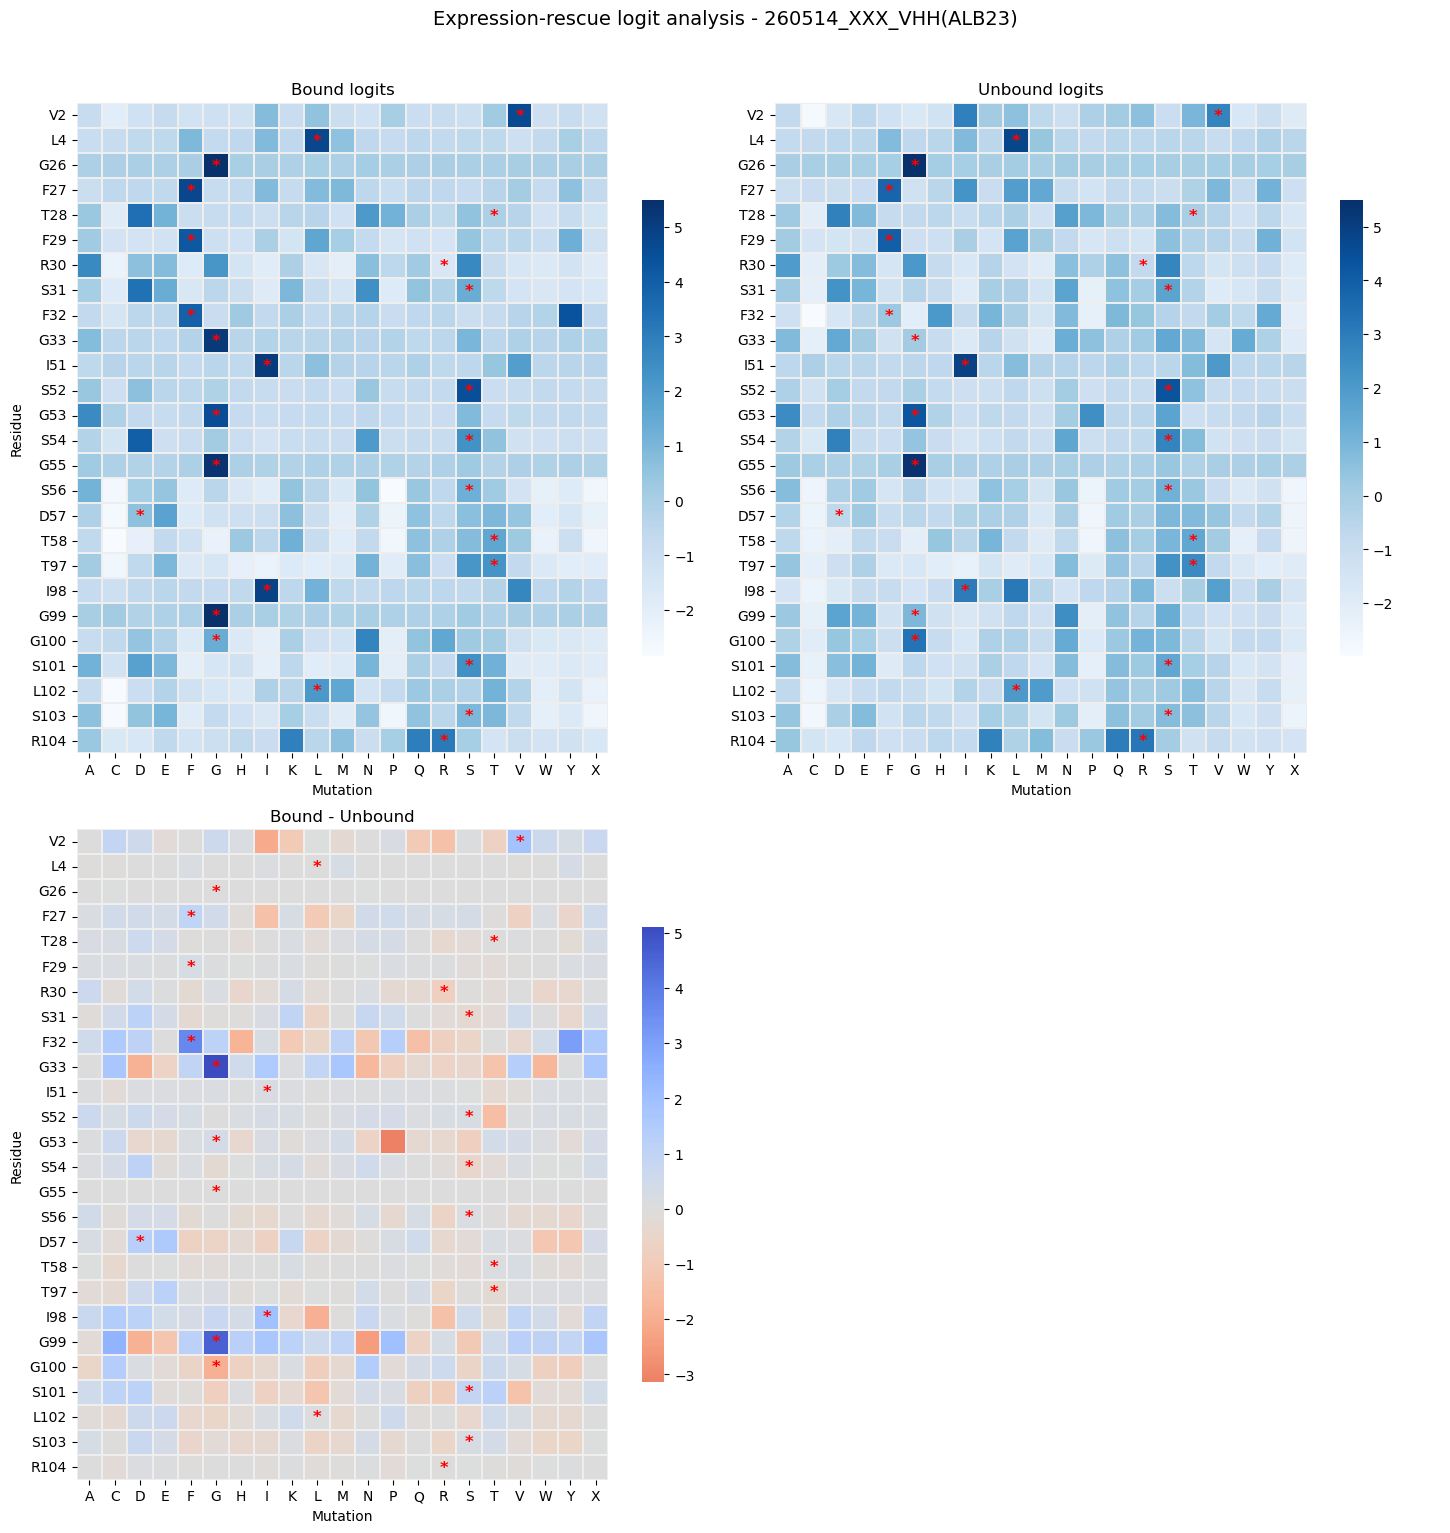

In [18]:
import math

# Color convention (consistent with the Step 8 3-D views): low = red, high = blue.
panels = [
    ("Bound logits", bound_mat, "Blues", None),
    ("Unbound logits", unbound_mat, "Blues", None),
    ("Bound - Unbound", diff_mat, "coolwarm_r", 0.0),
]

# 2열 레이아웃을 위한 행 수 계산 (3개 패널 / 2열 = 2행)
ncols = 2
nrows = math.ceil(len(panels) / ncols)

# figsize 조정: 열 개수와 행 개수에 맞춰 너비와 높이 조절
fig, axes = plt.subplots(
    nrows, ncols, figsize=(ncols * 0.3 * n_aa + 2, nrows * max(4, 0.3 * n_res))
)

# axes는 2D 배열이므로 반복문을 위해 1차원으로 평탄화(flatten)
axes_flat = axes.flatten()


for i, (title, mat, cmap, center) in enumerate(panels):
    ax = axes_flat[i]
    sns.heatmap(
        mat,
        ax=ax,
        cmap=cmap,
        center=center,
        xticklabels=alphabet,
        yticklabels=[f"{wt}{res[1:]}" for wt, res in zip(wt_aas, ordered_residues)],
        cbar_kws={"shrink": 0.7},
        linewidths=0.2,
        linecolor="#eeeeee",
    )
    ax.set_title(title)
    ax.set_xlabel("Mutation")

    # 각 행의 첫 번째 열에만 Residue 라벨 표시
    if i % ncols == 0:
        ax.set_ylabel("Residue")
    else:
        ax.set_ylabel("")

    # WT 위치에 별표(*) 표시
    for row_idx, wt in enumerate(wt_aas):
        col_idx = aa_to_col[wt]
        ax.text(
            col_idx + 0.5,
            row_idx + 0.5,
            "*",
            ha="center",
            va="center",
            color="red",
            fontsize=12,
            fontweight="bold",
        )

# 데이터가 없는 나머지 subplot(4번째 칸) 숨기기
for j in range(len(panels), len(axes_flat)):
    axes_flat[j].axis("off")

fig.suptitle(f"Expression-rescue logit analysis - {stem}", fontsize=14)
fig.tight_layout()

# 하단 여백 확보 (suptitle과 겹치지 않게)
plt.subplots_adjust(top=0.92)

heatmap_path = output_dir / "heatmap_2col.png"
# fig.savefig(heatmap_path, dpi=200, bbox_inches="tight")
plt.show()

## Step 8 - Logit 색상 PDB + 인라인 뷰어

B-factor 컬럼을 WT 아미노산 logit으로 교체한 두 개의 구조 파일을 생성합니다:

- `<stem>_logits.pdb` - 결합된 복합체, **결합 상태(bound-state)** logit으로 색상 지정
- `<stem>_unbound_logits.pdb` - 항원이 제거된 사본, **비결합 상태(unbound-state)** logit으로 색상 지정

두 구조 모두 `py3Dmol`을 사용하여 **red-white-blue** 그래디언트로 인라인 렌더링됩니다. **Red = 낮은 logit** (해당 위치에서 WT가 선호되지 않음 — 해당 상태에서 폴딩/결합에 불리함); **Blue = 높은 logit** (WT가 선호됨). Rescue 세트 이외의 잔기들은 컨텍스트 확인을 위해 밝은 회색으로 표시됩니다.

동일한 파일을 PyMOL에서 `spectrum b, red_white_blue` 명령어로 열어 더 정밀하게 확인할 수 있습니다.

In [ ]:
import matplotlib
import matplotlib.colors as mcolors


def write_logit_pdb(src_pdb, dst_pdb, logits_dict, wt_map):
    """Copy src_pdb to dst_pdb with B-factor replaced by each residue's WT logit."""
    wt_logit_by_res = {
        res_name: float(aa_dict.get(wt_map.get(res_name), 0.0))
        for res_name, aa_dict in logits_dict.items()
        if wt_map.get(res_name) is not None
    }
    with open(src_pdb) as f_in, open(dst_pdb, "w") as f_out:
        for line in f_in:
            if line.startswith(("ATOM", "HETATM")):
                chain = line[21]
                resnum = line[22:26].strip()
                res_key = f"{chain}{resnum}"
                score = wt_logit_by_res.get(res_key, 0.0)
                # B-factor column is columns 61-66 (0-indexed 60:66), 6.2f.
                line = line[:60] + f"{score:6.2f}" + line[66:]
            f_out.write(line)
    return wt_logit_by_res


bound_logit_pdb = output_dir / f"{stem}_logits.pdb"
unbound_logit_pdb = output_dir / f"{stem}_unbound_logits.pdb"

bound_wt_logits = write_logit_pdb(
    bound_pdb_path,
    bound_logit_pdb,
    bound_logits,
    wt_bound,
)
unbound_wt_logits = write_logit_pdb(
    unbound_pdb_path,
    unbound_logit_pdb,
    unbound_logits,
    wt_unbound,
)


# Color convention: low logit (WT not preferred) = red, high logit (WT preferred) = blue.
def show_logit_structure(
    pdb_path, wt_logit_by_res, vmin, vmax, title, cmap_name="bwr_r"
):
    """Render a PDB inline with py3Dmol, cartoon colored per-residue by logit."""
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    cmap = matplotlib.colormaps[cmap_name]

    with open(pdb_path) as f:
        pdb_text = f.read()
    view = py3Dmol.view(width=500, height=400)
    view.addModel(pdb_text, "pdb")
    view.setStyle({}, {"cartoon": {"color": "lightgray"}})
    for res_name, score in wt_logit_by_res.items():
        m = re.match(r"([A-Za-z]+)(\d+)", res_name)
        if not m:
            continue
        chain, resnum = m.group(1), m.group(2)
        hex_color = mcolors.to_hex(cmap(norm(score)))
        view.setStyle(
            {"chain": chain, "resi": resnum},
            {"cartoon": {"color": hex_color}},
        )
    view.zoomTo()
    display(Markdown(f"**{title}**"))
    display({"text/html": view._repr_html_()}, raw=True)


# 두 패널을 직접 비교할 수 있도록 동일한 색상 스케일을 공유합니다.
all_scores = list(bound_wt_logits.values()) + list(unbound_wt_logits.values())
vmin, vmax = float(min(all_scores)), float(max(all_scores))

display(
    Markdown(
        f"`{bound_logit_pdb.name}` 및 `{unbound_logit_pdb.name}` 파일을 `{output_dir}`에 저장했습니다.\n\n"
        f"공유 색상 스케일: **{vmin:+.2f}** (Red, WT 비선호) → "
        f"**{vmax:+.2f}** (Blue, WT 선호)."
    )
)

show_logit_structure(bound_logit_pdb, bound_wt_logits, vmin, vmax, "결합 상태 (Bound)")
show_logit_structure(
    unbound_logit_pdb, unbound_wt_logits, vmin, vmax, "비결합 상태 (Unbound)"
)

display(
    Markdown(
        "**PyMOL에서 더 정밀하게 보는 명령어:**\n"
        f"```\n"
        f"pymol {bound_logit_pdb} -d 'spectrum b, red_white_blue'\n"
        f"pymol {unbound_logit_pdb} -d 'spectrum b, red_white_blue'\n"
        f"```"
    )
)

`260514_XXX_VHH(ALB23)_logits.pdb` 및 `260514_XXX_VHH(ALB23)_unbound_logits.pdb` 파일을 `/home/fkt/Downloads/repo/ab-expression-rescue/output`에 저장했습니다.

공유 색상 스케일: **-1.60** (Red, WT 비선호) → **+5.88** (Blue, WT 선호).

**결합 상태 (Bound)**

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

**비결합 상태 (Unbound)**

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

**PyMOL에서 더 정밀하게 보기:**
```
pymol /home/fkt/Downloads/repo/ab-expression-rescue/output/260514_XXX_VHH(ALB23)_logits.pdb -d 'spectrum b, red_white_blue'
pymol /home/fkt/Downloads/repo/ab-expression-rescue/output/260514_XXX_VHH(ALB23)_unbound_logits.pdb -d 'spectrum b, red_white_blue'
```

## 결과 해석

**최종 결과는 Step 6 출력 상단의 녹색 "Final rescue mutations" 박스입니다** . 해당 치환을 항체 서열에 도입하고, 재발현시킨 후 발현율과 결합력을 측정하십시오. 그 외의 모든 것(순위 표, 히트맵, 3D 뷰, 잔기별 CSV)은 이러한 돌연변이가 어떻게 선택되었는지 이해를 돕는 **추가 정보**입니다. 대부분의 사용자는 최종 목록에 의심스러운 점이 없는 한 이를 무시해도 됩니다.

**출력 품질은 입력 구조의 품질에 따라 달라집니다.** 이 파이프라인은 잔기별 구조적 컨텍스트(백본 기하 구조 + 주변 환경)를 읽어 모든 후속 결정을 내리는 logit을 생성합니다. 입력된 복합체의 해상도가 낮거나, 잘못 폴딩된 영역이 있거나, 품질이 좋지 않은 경우 결과로 나온 rescue 돌연변이를 신뢰하기 어려울 수 있습니다. 최종 돌연변이 목록이 이상해 보인다면(예: 선택된 위치가 인터페이스에서 너무 멀거나, 명백한 핫스팟에 결합 플래그가 누락된 경우), 임계값을 재조정하기 전에 먼저 입력 구조의 품질을 의심해 보십시오.

돌연변이가 선택된 이유를 더 자세히 알고 싶다면:

- **`key_binding_residues.csv`** — 어떤 위치가 플래그 지정되었는지 확인 (Δ 기반 + 사용자 지정 + 최종 세트)
- **`rescue_ranking.csv`** — 전체 정렬 목록; `top_k=True`인 행들이 녹색 박스에 표시된 것들입니다.
- **`heatmap.png`** — 결합 / 비결합 / 차이에 대한 잔기별 21개 아미노산 logit 그리드
- **`<stem>_logits.pdb`** / **`<stem>_unbound_logits.pdb`** — 구조의 B-factor에 logit을 입힌 파일 (PyMOL에서 `spectrum b, red_white_blue`로 확인 가능)
- **Step 8 인라인 3D 뷰** — 위와 동일한 내용을 노트북 내에서 확인 (GitHub에서는 대화형 위젯이 렌더링되지 않을 수 있습니다; 노트북 상단 배너 참조)

전체적인 색상 규칙: **Red = 낮은 logit (WT 비선호) · Blue = 높은 logit (WT 선호)**.

인용: Dauparas et al. 2022 (ProteinMPNN), 2025 (LigandMPNN).